In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [2]:

# Simple MLP for the noise prediction network
class SimpleUNet(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=128, time_dim=16):
        super().__init__()
        
        # Time embedding
        self.time_mlp = nn.Sequential(
            nn.Linear(1, time_dim),
            nn.ReLU(),
            nn.Linear(time_dim, time_dim)
        )
        
        # Main network
        self.net = nn.Sequential(
            nn.Linear(input_dim + time_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )
    
    def forward(self, x, t):
        # t shape: (batch_size, 1)
        t_emb = self.time_mlp(t)
        x_and_t = torch.cat([x, t_emb], dim=1)
        return self.net(x_and_t)


class SimpleDiffusion:
    def __init__(self, num_timesteps=1000, beta_start=1e-4, beta_end=0.02):
        self.num_timesteps = num_timesteps
        
        # Linear schedule for betas
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        
    def forward_diffusion(self, x0, t):
        """Add noise to data at timestep t"""
        batch_size = x0.shape[0]
        
        # Sample noise
        noise = torch.randn_like(x0)
        
        # Get alpha values for timestep t
        alpha_t = self.alphas_cumprod[t].view(batch_size, 1)
        
        # Add noise: x_t = sqrt(alpha_t) * x0 + sqrt(1 - alpha_t) * noise
        noisy_x = torch.sqrt(alpha_t) * x0 + torch.sqrt(1 - alpha_t) * noise
        
        return noisy_x, noise
    
    @torch.no_grad()
    def sample(self, model, n_samples=500, device='cpu'):
        """Generate samples using the reverse diffusion process"""
        model.eval()
        
        # Start from pure noise
        x = torch.randn(n_samples, 2).to(device)
        
        # Reverse diffusion
        for t in reversed(range(self.num_timesteps)):
            t_batch = torch.full((n_samples,), t, dtype=torch.long).to(device)
            
            # Predict noise
            t_normalized = (t_batch.float() / self.num_timesteps).view(-1, 1)
            predicted_noise = model(x, t_normalized)
            
            # Get parameters for timestep t
            beta_t = self.betas[t]
            alpha_t = self.alphas[t]
            alpha_cumprod_t = self.alphas_cumprod[t]
            
            # x_{t-1} = (1/sqrt(alpha_t)) * (x_t - (beta_t/sqrt(1-alpha_cumprod_t)) * noise) + sigma * z
            '''
            x1 = (1 / torch.sqrt(alpha_t)) * (x2 - (beta_t / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise)
            torch.sqrt(alpha_t) * x1 = x2 - (beta_t / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise
            torch.sqrt(alpha_t) * x1 + (beta_t / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise = x2
            '''
            x = (1 / torch.sqrt(alpha_t)) * (x - (beta_t / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise)
            
            if t > 0:
                noise = torch.randn_like(x)
                sigma = torch.sqrt(beta_t)
                x = x + sigma * noise
        
        return x


def get_swiss_roll_data(n_samples=2000):
    """Generate 2D Swiss roll dataset"""
    data, _ = make_swiss_roll(n_samples=n_samples, noise=0.1)
    # Use only x and z coordinates for 2D visualization
    data = data[:, [0, 2]]
    # Normalize
    data = (data - data.mean(axis=0)) / data.std(axis=0)
    return torch.FloatTensor(data)


def visualize_results(model, diffusion, original_data):
    """Visualize the original data and generated samples"""
    # Generate samples
    generated_samples = diffusion.sample(model, n_samples=500)
    
    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Original data
    ax1.scatter(original_data[:, 0], original_data[:, 1], alpha=0.5, s=10)
    ax1.set_title("Original Swiss Roll Data")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    
    # Generated data
    ax2.scatter(generated_samples[:, 0], generated_samples[:, 1], alpha=0.5, s=10, c='orange')
    ax2.set_title("Generated Samples")
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    
    plt.tight_layout()
    plt.show()#savefig('/home/claude/diffusion_results.png', dpi=150, bbox_inches='tight')
    print("\nVisualization saved to diffusion_results.png")


In [3]:

def train_diffusion_model(model=None, diffusion=None, optimizer=None, data=None, epochs=100, batch_size=128):
    """Train the diffusion model"""

    # Training loop
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        num_batches = 0
        
        # Shuffle data
        perm = torch.randperm(data.shape[0])
        data_shuffled = data[perm]
        
        for i in range(0, data.shape[0], batch_size):
            batch = data_shuffled[i:i+batch_size].to(device)
            
            # Sample random timesteps
            t = torch.randint(0, diffusion.num_timesteps, (batch.shape[0],))
            
            # Forward diffusion (add noise)
            noisy_x, noise = diffusion.forward_diffusion(batch, t)
            
            # Predict noise
            t_normalized = (t.float() / diffusion.num_timesteps).view(-1, 1).to(device)
            predicted_noise = model(noisy_x, t_normalized)
            
            # Calculate loss
            loss = nn.functional.mse_loss(predicted_noise, noise)
            
            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/num_batches:.4f}")
    
    return model, diffusion, data

Text(0.5, 1.0, 'Betas')

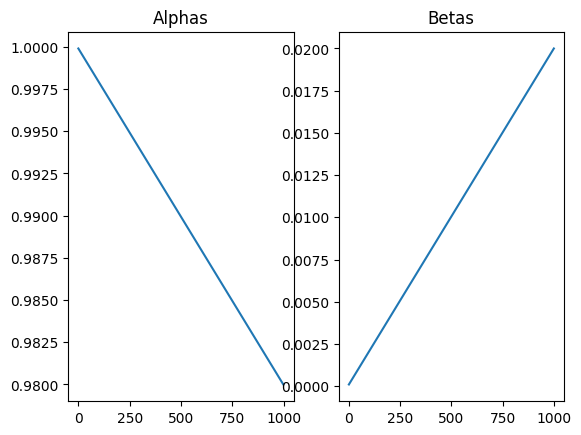

In [8]:
plt.subplot(121)
plt.plot(diffusion.alphas);plt.title('Alphas')
plt.subplot(122)
plt.plot(diffusion.betas);plt.title('Betas')

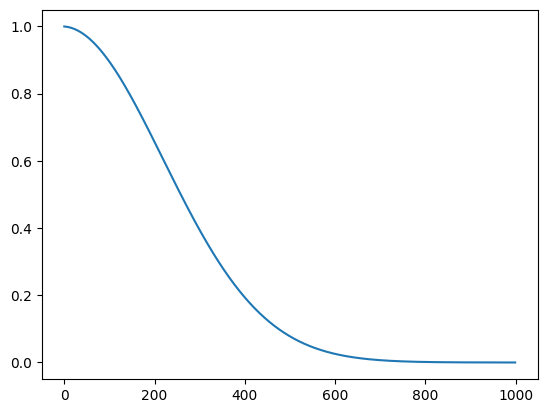

In [7]:

plt.plot(diffusion.alphas_cumprod)#.view(-1,1)

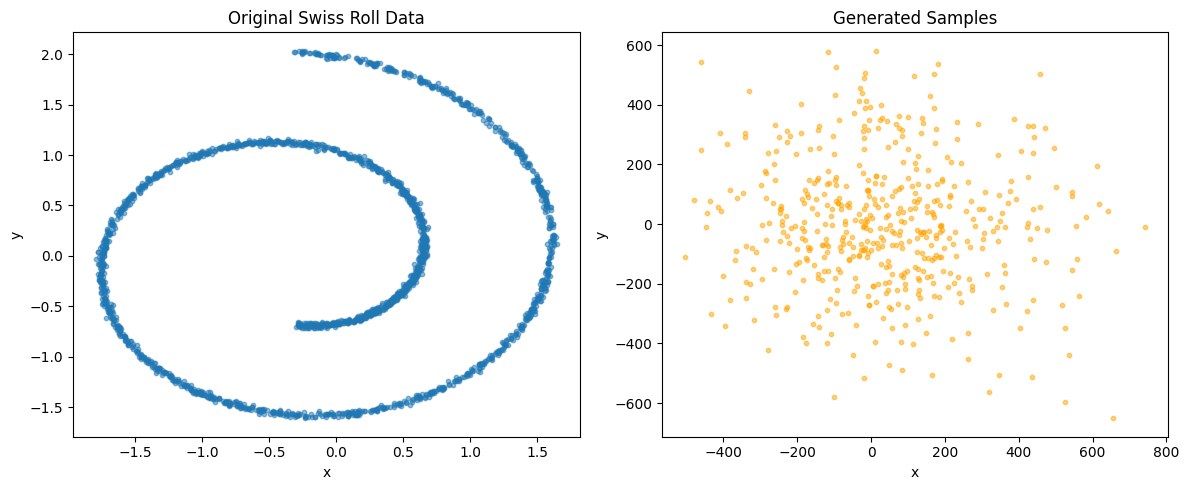


Visualization saved to diffusion_results.png
Epoch 20/100, Loss: 0.2789
Epoch 40/100, Loss: 0.2429
Epoch 60/100, Loss: 0.2527
Epoch 80/100, Loss: 0.2525
Epoch 100/100, Loss: 0.2438


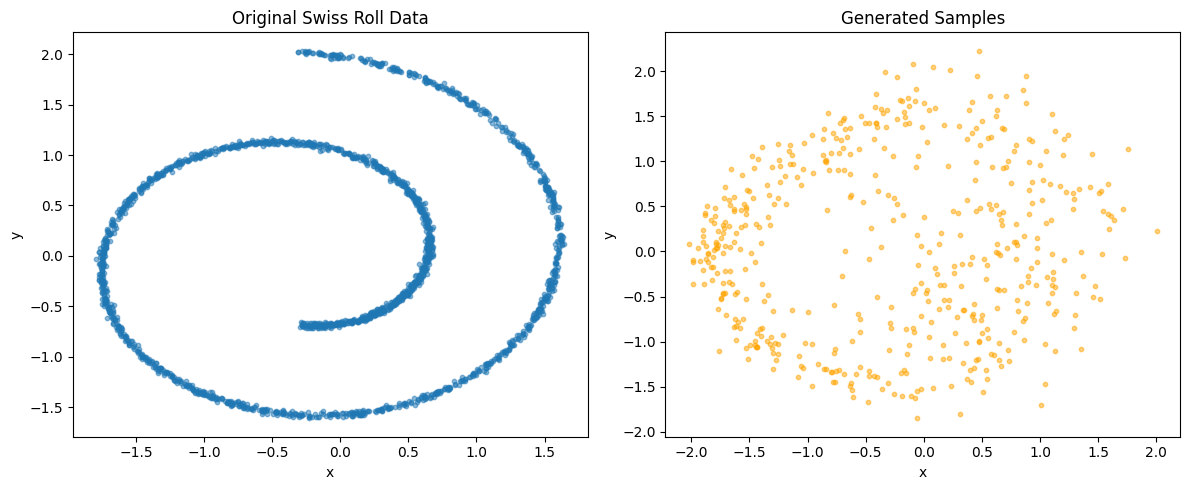


Visualization saved to diffusion_results.png
Epoch 20/200, Loss: 0.2690
Epoch 40/200, Loss: 0.2428
Epoch 60/200, Loss: 0.2581
Epoch 80/200, Loss: 0.2125
Epoch 100/200, Loss: 0.2346
Epoch 120/200, Loss: 0.2721
Epoch 140/200, Loss: 0.2514
Epoch 160/200, Loss: 0.2458
Epoch 180/200, Loss: 0.2453
Epoch 200/200, Loss: 0.2462


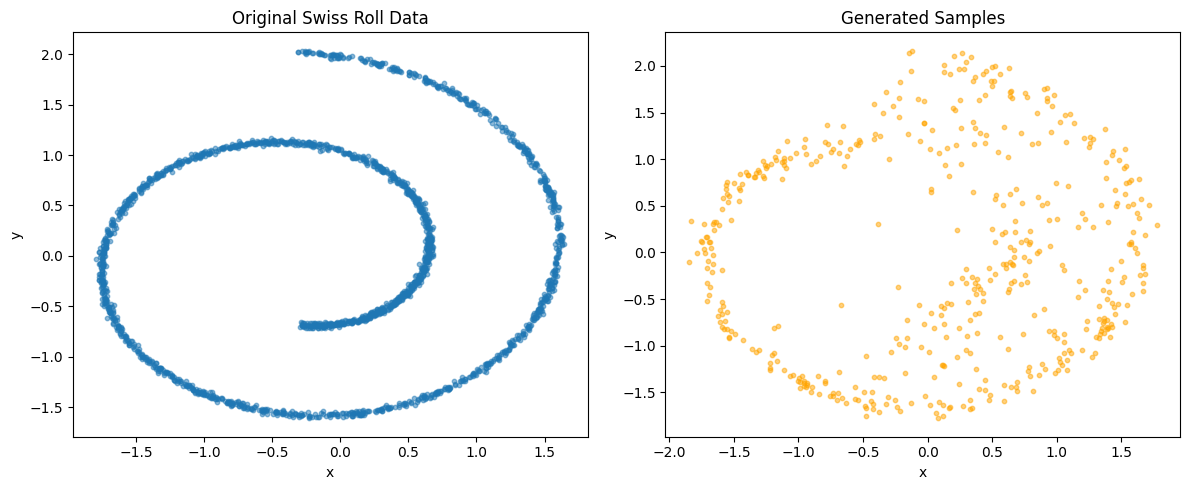


Visualization saved to diffusion_results.png
Epoch 20/200, Loss: 0.2523
Epoch 40/200, Loss: 0.2538
Epoch 60/200, Loss: 0.2305
Epoch 80/200, Loss: 0.2547
Epoch 100/200, Loss: 0.2424
Epoch 120/200, Loss: 0.2341
Epoch 140/200, Loss: 0.2383
Epoch 160/200, Loss: 0.2265
Epoch 180/200, Loss: 0.2359
Epoch 200/200, Loss: 0.2167


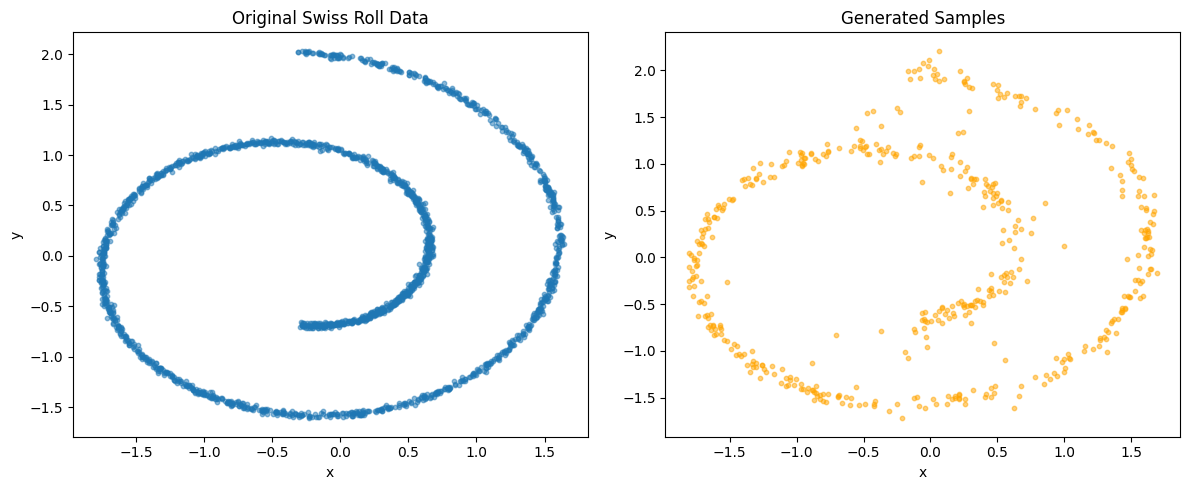


Visualization saved to diffusion_results.png
Epoch 20/300, Loss: 0.2412
Epoch 40/300, Loss: 0.2566
Epoch 60/300, Loss: 0.2259
Epoch 80/300, Loss: 0.2239
Epoch 100/300, Loss: 0.2259
Epoch 120/300, Loss: 0.2486
Epoch 140/300, Loss: 0.2522
Epoch 160/300, Loss: 0.2340
Epoch 180/300, Loss: 0.2428
Epoch 200/300, Loss: 0.2428
Epoch 220/300, Loss: 0.2470
Epoch 240/300, Loss: 0.2119
Epoch 260/300, Loss: 0.2214
Epoch 280/300, Loss: 0.2279
Epoch 300/300, Loss: 0.2354


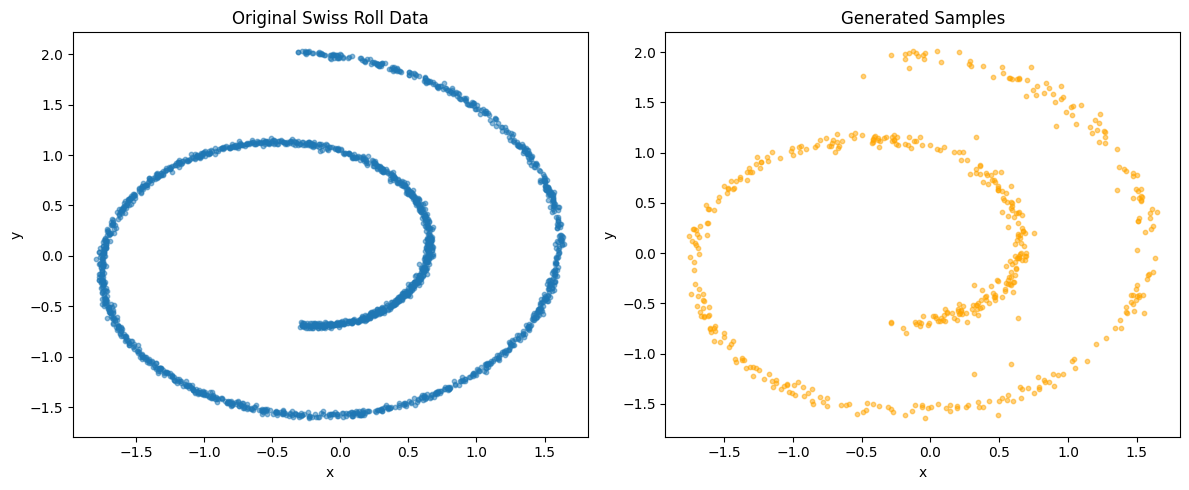


Visualization saved to diffusion_results.png


In [5]:
device = 'cpu'  # Use CPU for lightweight training

# Get data
data = get_swiss_roll_data(n_samples=2000)

# Initialize model and diffusion
model = SimpleUNet().to(device)
diffusion = SimpleDiffusion(num_timesteps=1000)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


visualize_results(model, diffusion, data)
model, diffusion, data = train_diffusion_model(
    model=model, diffusion=diffusion, optimizer=optimizer, data=data, epochs=100, batch_size=128)

visualize_results(model, diffusion, data)
model, diffusion, data = train_diffusion_model(
    model=model, diffusion=diffusion, optimizer=optimizer, data=data, epochs=200, batch_size=128)

visualize_results(model, diffusion, data)
model, diffusion, data = train_diffusion_model(
    model=model, diffusion=diffusion, optimizer=optimizer, data=data, epochs=200, batch_size=128)

visualize_results(model, diffusion, data)
model, diffusion, data = train_diffusion_model(
    model=model, diffusion=diffusion, optimizer=optimizer, data=data, epochs=300, batch_size=128)


visualize_results(model, diffusion, data)